<a href="https://colab.research.google.com/github/Preethi-140306/MLOPS_Training/blob/main/Project_Implemented_train_test_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
from google.colab import files
uploaded = files.upload()

Saving women_safety_text_dataset.csv to women_safety_text_dataset.csv


In [80]:
import pandas as pd
df = pd.read_csv('women_safety_text_dataset_1000.csv')
df.head(20)

,id,text,label,alert_level,confidence_score,camera_id,location,time,city,split
0,1,Woman jogging with earphones at bus stop at 9:...,safe,LOW,0.80,CAM-31-F,bus stop,9:00 PM,Kolkata,test
1,2,Surveillance flagged: woman walking alone at t...,lone_walking_night,MEDIUM,0.73,CAM-85-E,temple road,12:45 AM,Jaipur,train
2,3,Urban command center log: bus stop camera flag...,monitoring,LOW,0.77,CAM-96-B,bus stop,12:15 AM,Bangalore,test
3,4,SOS gesture pattern detected near metro statio...,distress_signal,HIGH,0.75,CAM-93-D,metro station,2:00 AM,Lucknow,train
4,5,AI pipeline triggered at marketplace camera gr...,monitoring,LOW,0.78,CAM-29-E,marketplace,3:00 AM,Lucknow,train
5,6,Woman detected walking alone at railway platfo...,lone_walking_night,MEDIUM,0.98,CAM-75-E,railway platform,9:00 PM,Delhi,train
6,7,Vehicle slowing repeatedly near pedestrian at ...,threat_detected,HIGH,0.97,CAM-71-E,college campus,5:30 PM,Hyderabad,train
7,8,Command center to field unit: Respond to bus s...,being_followed,CRITICAL,0.83,CAM-84-C,bus stop,11:00 AM,Delhi,train
8,9,CCTV integration alert: metro station at 9:00 ...,monitoring,LOW,0.77,CAM-20-D,metro station,9:00 PM,Chennai,train
9,10,AI body language analysis: subject at resident...,distress_signal,HIGH,0.85,CAM-09-H,residential lane,9:00 PM,Mumbai,train


In [67]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['encoded_text'] = le.fit_transform(df['text'])
df.head()

,id,text,label,alert_level,confidence_score,camera_id,location,time,city,split,label_transform,encoded_text
0,1,Woman jogging with earphones at bus stop at 9:...,safe,LOW,0.80,CAM-31-F,bus stop,9:00 PM,Kolkata,test,5,949
1,2,Surveillance flagged: woman walking alone at t...,lone_walking_night,MEDIUM,0.73,CAM-85-E,temple road,12:45 AM,Jaipur,train,3,739
2,3,Urban command center log: bus stop camera flag...,monitoring,LOW,0.77,CAM-96-B,bus stop,12:15 AM,Bangalore,test,4,824
3,4,SOS gesture pattern detected near metro statio...,distress_signal,HIGH,0.75,CAM-93-D,metro station,2:00 AM,Lucknow,train,1,591
4,5,AI pipeline triggered at marketplace camera gr...,monitoring,LOW,0.78,CAM-29-E,marketplace,3:00 AM,Lucknow,train,4,111


In [66]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label_transform'] = le.fit_transform(df['label'])
df.head()

,id,text,label,alert_level,confidence_score,camera_id,location,time,city,split,label_transform
0,1,Woman jogging with earphones at bus stop at 9:...,safe,LOW,0.80,CAM-31-F,bus stop,9:00 PM,Kolkata,test,5
1,2,Surveillance flagged: woman walking alone at t...,lone_walking_night,MEDIUM,0.73,CAM-85-E,temple road,12:45 AM,Jaipur,train,3
2,3,Urban command center log: bus stop camera flag...,monitoring,LOW,0.77,CAM-96-B,bus stop,12:15 AM,Bangalore,test,4
3,4,SOS gesture pattern detected near metro statio...,distress_signal,HIGH,0.75,CAM-93-D,metro station,2:00 AM,Lucknow,train,1
4,5,AI pipeline triggered at marketplace camera gr...,monitoring,LOW,0.78,CAM-29-E,marketplace,3:00 AM,Lucknow,train,4


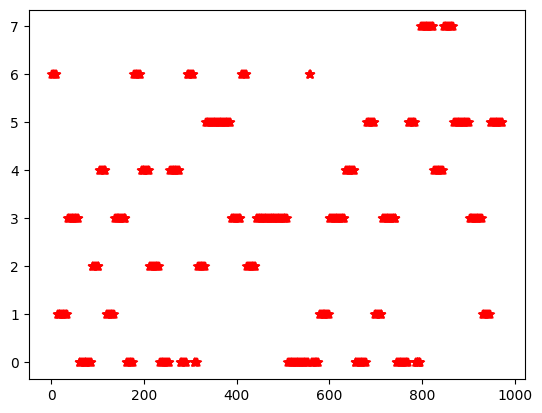

In [68]:
import matplotlib.pyplot as plt
plt.scatter(df['encoded_text'],df['label_transform'],color='red',marker='*')
plt.show()

In [69]:
df['text_length']=df['text'].str.len()
df.head()

,id,text,label,alert_level,confidence_score,camera_id,location,time,city,split,label_transform,encoded_text,text_length
0,1,Woman jogging with earphones at bus stop at 9:...,safe,LOW,0.80,CAM-31-F,bus stop,9:00 PM,Kolkata,test,5,949,99
1,2,Surveillance flagged: woman walking alone at t...,lone_walking_night,MEDIUM,0.73,CAM-85-E,temple road,12:45 AM,Jaipur,train,3,739,114
2,3,Urban command center log: bus stop camera flag...,monitoring,LOW,0.77,CAM-96-B,bus stop,12:15 AM,Bangalore,test,4,824,113
3,4,SOS gesture pattern detected near metro statio...,distress_signal,HIGH,0.75,CAM-93-D,metro station,2:00 AM,Lucknow,train,1,591,107
4,5,AI pipeline triggered at marketplace camera gr...,monitoring,LOW,0.78,CAM-29-E,marketplace,3:00 AM,Lucknow,train,4,111,121


In [70]:
X=df['encoded_text']
y=df['label_transform']

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train


,encoded_text
560,347
803,58
413,956
20,439
792,931
...,...
687,690
767,309
5,923
753,252


In [72]:
X_test

,encoded_text
707,735
231,130
846,80
651,365
246,815
...,...
372,455
531,732
244,77
227,584


In [73]:
y_train

,label_transform
560,5
803,3
413,5
20,2
792,1
...,...
687,5
767,0
5,3
753,0


In [74]:
y_test

,label_transform
707,3
231,1
846,0
651,5
246,7
...,...
372,3
531,3
244,0
227,1


In [75]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train.to_frame(),y_train)

LinearRegression()

In [77]:
model.predict(X_test.to_frame())

array([3.21919621, 2.34499862, 2.27275089, 2.68456298, 3.33479258,
       3.51685687, 2.48515923, 3.47495319, 2.82183367, 3.39548068,
       3.47350823, 2.3522234 , 2.55451705, 3.21052648, 3.12238425,
       2.16871415, 3.00823283, 2.32765917, 3.56020551, 2.56029687,
       3.4778431 , 2.99667319, 2.20917288, 3.46772842, 3.5414211 ,
       2.17738388, 2.25107657, 3.08481542, 2.73658134, 3.32178799,
       3.41426509, 2.44903536, 2.96343923, 2.92153554, 3.55876056,
       2.41869131, 3.46050364, 2.89841627, 3.00678787, 2.95621446,
       2.79582449, 2.41002159, 2.50683355, 2.97788878, 3.1556182 ,
       2.16293433, 3.1845173 , 2.62820974, 2.36522799, 2.79293458,
       2.51983814, 2.92731536, 2.76403548, 2.25396648, 3.24954026,
       2.9865585 , 2.79004467, 2.86373736, 2.97933373, 2.82038872,
       3.46050364, 2.30453989, 3.10359983, 2.68167307, 2.38690231,
       3.3246779 , 3.32034304, 2.90130618, 3.02412733, 3.36369168,
       3.0790356 , 2.49671887, 3.37814122, 3.11804938, 2.98077

In [78]:
model.score(X_test.to_frame(),y_test)

0.039923778221692574